# Hafta 1 · Ders 2 — Nokta İşlemleri ve Histogramlar

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

En basit görüntü dönüşümleri **her seferinde bir piksele** dokunur: yeni değer yalnızca aynı
konumdaki eski değere bağlıdır, asla komşularına değil. Bu **nokta işlemleri** — parlaklık, kontrast,
gama, eşikleme — her piksele uygulanan tek bir *eşleme eğrisi* ile tanımlanır.

Bu eğrileri iyi seçmek için görüntünün **histogramını** okuruz: yoğunluklarının dağılımı.
Histogram, görüntü işlemedeki en faydalı tek-bakışta tanı aracıdır ve **histogram eşitleme**
onu otomatik bir kontrast-iyileştirme algoritmasına dönüştürür.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.cv_utils import show, show_row, sample_gray, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Eşleme eğrileri olarak nokta işlemleri

Bir nokta işlemi, her piksel yoğunluğu $f$'e bağımsız olarak uygulanan bir $g = T(f)$ fonksiyonudur.
Üç temel işlem:

- **Parlaklık:** $g = f + b$ (eğriyi yukarı/aşağı kaydır)
- **Kontrast:** $g = a\\,(f - 0.5) + 0.5$ (orta-griye göre ger)
- **Gama:** $g = f^{\\gamma}$ (doğrusal olmayan — orta tonları açar veya koyulaştırır)

$T$'yi girişten çıkışa bir eğri olarak çizmek, daha uygulamadan önce işlemin *tam olarak* ne
yaptığını söyler.

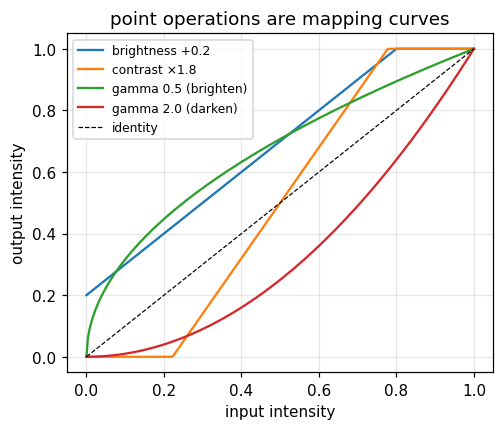

In [2]:
img = sample_gray(128)
x = np.linspace(0, 1, 256)

def brightness(f, b):  return np.clip(f + b, 0, 1)
def contrast(f, a):    return np.clip(a * (f - 0.5) + 0.5, 0, 1)
def gamma(f, g):       return np.clip(f ** g, 0, 1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x, brightness(x, 0.2), label="parlaklık +0.2")
ax.plot(x, contrast(x, 1.8),   label="kontrast ×1.8")
ax.plot(x, gamma(x, 0.5),      label="gama 0.5 (açar)")
ax.plot(x, gamma(x, 2.0),      label="gama 2.0 (koyulaştırır)")
ax.plot(x, x, "k--", lw=0.8, label="özdeşlik")
ax.set_xlabel("giriş yoğunluğu"); ax.set_ylabel("çıkış yoğunluğu")
ax.set_title("nokta işlemleri eşleme eğrileridir"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

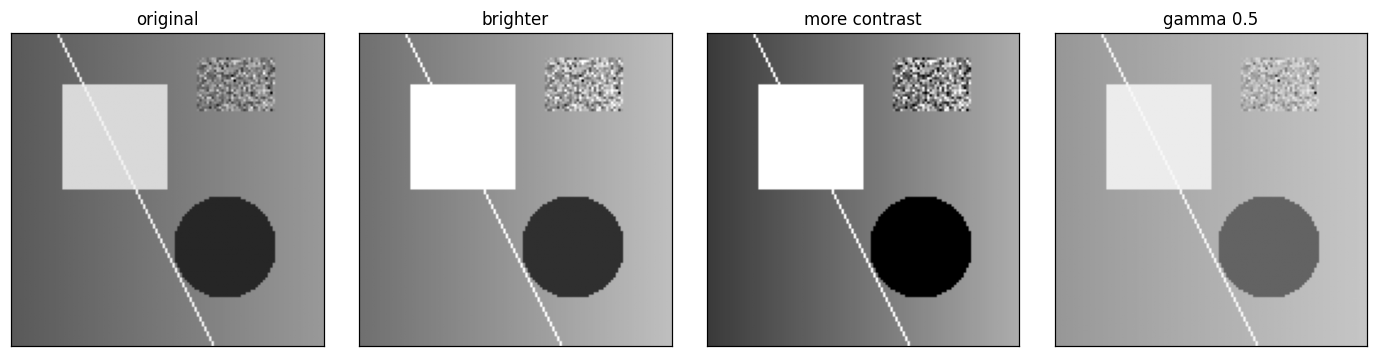

In [3]:
show_row([img, brightness(img, 0.2), contrast(img, 1.8), gamma(img, 0.5)],
         ["orijinal", "daha parlak", "daha fazla kontrast", "gama 0.5"])
plt.show()

## 2. The histogram: an image's intensity fingerprint

The **histogram** counts how many pixels fall in each intensity bin. It ignores *where* pixels are and
captures only *how bright* they are — yet it reveals exposure, contrast, and dynamic range at a glance.
A dark image piles up on the left; a low-contrast image bunches in a narrow band. Let's compute one
from scratch.

[PASS] histogram sums to #pixels          max|Δ| = 0.00e+00
[PASS] histogram vs np.histogram          max|Δ| = 0.00e+00


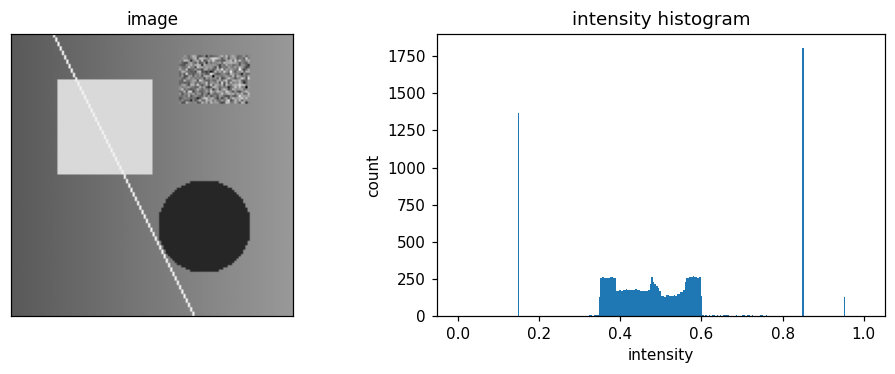

In [4]:
def histogram(im, bins=256):
    idx = np.clip((im * bins).astype(int), 0, bins - 1)
    counts = np.zeros(bins, dtype=int)
    np.add.at(counts, idx.ravel(), 1)        # her pikseli dağıtarak say
    return counts

h = histogram(img)
# toplamın piksel sayısına eşit olduğunu ve numpy'a karşı doğrula (aynı taban-tabanlı kovalama)
check("histogram toplamı == #piksel", h.sum(), img.size)
ref, _ = np.histogram(img, bins=256, range=(0, 1))
check("histogram vs np.histogram", h, ref)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
show(img, "görüntü", ax=axes[0])
axes[1].bar(np.linspace(0, 1, 256), h, width=1/256, color="C0")
axes[1].set_title("yoğunluk histogramı"); axes[1].set_xlabel("yoğunluk"); axes[1].set_ylabel("sayı")
plt.tight_layout(); plt.show()

## 3. Thresholding: histogram → binary image

The simplest segmentation: pick a threshold $t$ and set every pixel above it to white, below to black.
Where to put $t$? Often *between the peaks* of a bimodal histogram. **Otsu's method** automates this by
choosing the threshold that maximizes the variance *between* the two resulting groups — we implement it
from scratch.

Otsu threshold: 0.647


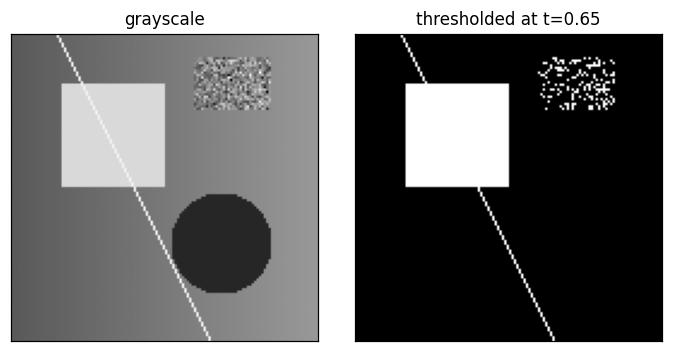

In [5]:
def otsu_threshold(im, bins=256):
    h = histogram(im, bins).astype(float)
    p = h / h.sum()                              # her yoğunluğun olasılığı
    levels = np.linspace(0, 1, bins)
    best_t, best_var = 0.0, -1.0
    for k in range(1, bins):
        w0 = p[:k].sum(); w1 = p[k:].sum()
        if w0 == 0 or w1 == 0:
            continue
        mu0 = (levels[:k] * p[:k]).sum() / w0
        mu1 = (levels[k:] * p[k:]).sum() / w1
        between = w0 * w1 * (mu0 - mu1) ** 2     # sınıflar-arası varyans
        if between > best_var:
            best_var, best_t = between, levels[k]
    return best_t

t = otsu_threshold(img)
binary = (img > t).astype(float)
print("Otsu eşiği:", round(t, 3))
show_row([img, binary], ["gri tonlama", f"t={t:.2f}'de eşiklenmiş"])
plt.show()

## 4. Histogram equalization: automatic contrast

If an image's intensities crowd into a narrow band, contrast is poor. **Histogram equalization**
spreads them out to use the full range by remapping intensities through the **cumulative distribution
function (CDF)** of the histogram. The CDF *is* the optimal mapping curve — it pulls dense regions
apart and compresses sparse ones, flattening the histogram.

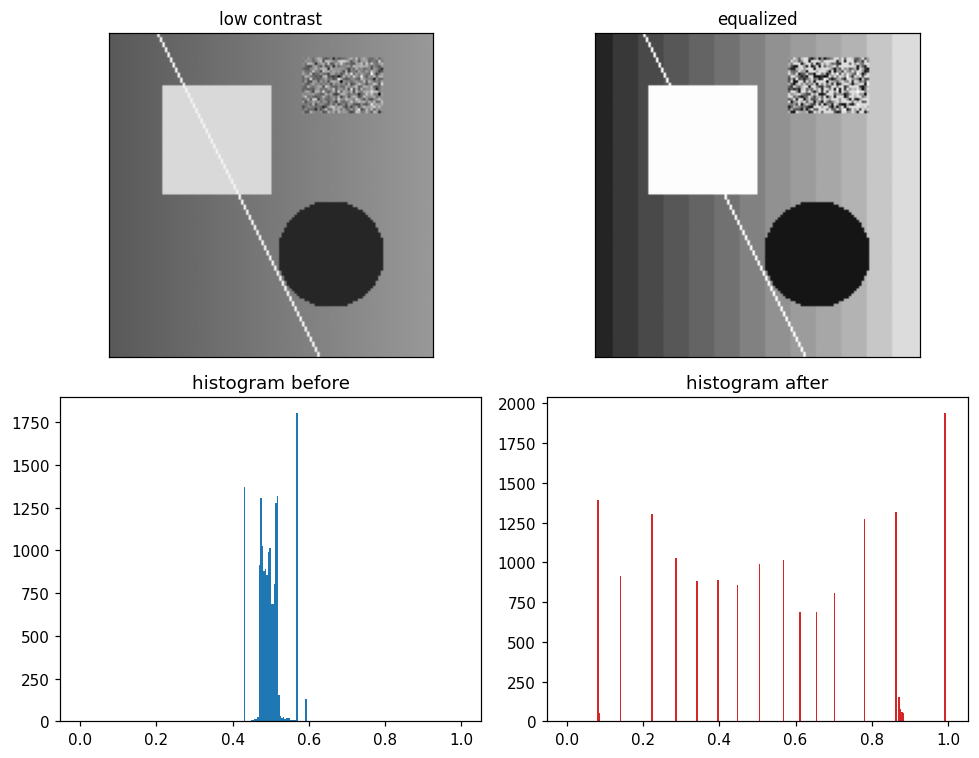

dynamic range before: 0.2  after: 1.0


In [6]:
def equalize(im, bins=256):
    h = histogram(im, bins).astype(float)
    cdf = np.cumsum(h) / h.sum()                 # eşleme eğrisi, [0,1] aralığında
    idx = np.clip((im * (bins - 1)).round().astype(int), 0, bins - 1)
    return cdf[idx]

# düzeltmek için kasıtlı olarak düşük kontrastlı bir görüntü oluştur
low = 0.4 + 0.2 * img
eq = equalize(low)

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
show(low, "düşük kontrast", ax=axes[0, 0])
show(eq,  "eşitlenmiş",    ax=axes[0, 1])
axes[1, 0].bar(np.linspace(0,1,256), histogram(low), width=1/256, color="C0"); axes[1,0].set_title("önceki histogram")
axes[1, 1].bar(np.linspace(0,1,256), histogram(eq),  width=1/256, color="C3"); axes[1,1].set_title("sonraki histogram")
plt.tight_layout(); plt.show()

print("önceki dinamik aralık:", round(low.max()-low.min(), 2), " sonraki:", round(eq.max()-eq.min(), 2))

## 5. Where this shows up in modern vision

- **Data augmentation.** Random brightness, contrast, and gamma jitter — exactly these point
  operations — are standard tricks to make CNNs robust to lighting.
- **Normalization layers.** Per-image and per-batch normalization generalize histogram stretching to
  keep activations well-scaled during training.
- **Activation functions** are point operations on feature maps: ReLU is a threshold, sigmoid is a
  smooth S-curve — the same mapping-curve idea applied to learned features.

A quick augmentation preview: random photometric jitter.

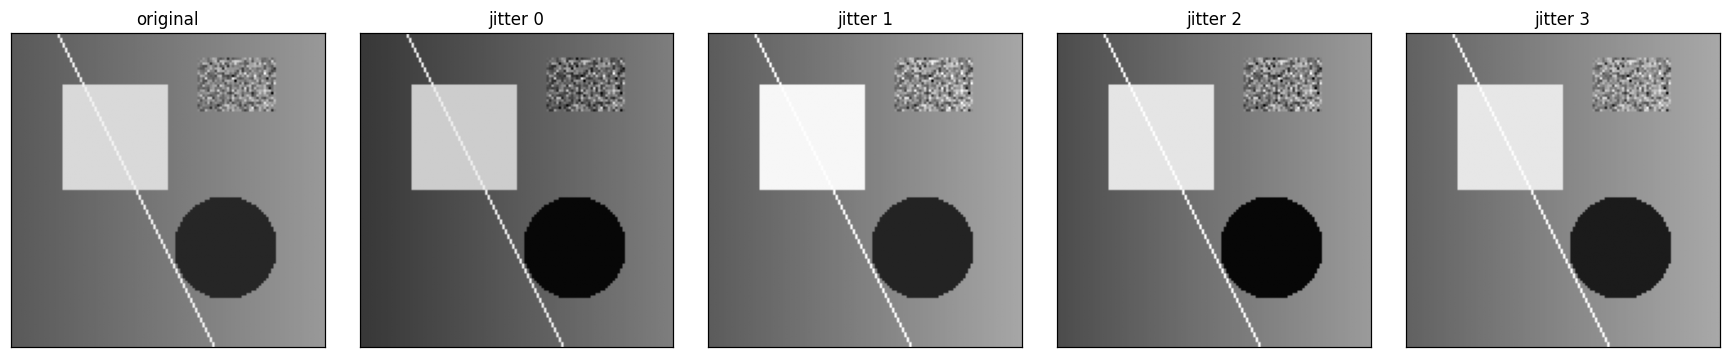

In [7]:
def augment(im, seed):
    rng = np.random.default_rng(seed)
    out = gamma(im, rng.uniform(0.6, 1.6))
    out = brightness(out, rng.uniform(-0.15, 0.15))
    out = contrast(out, rng.uniform(0.8, 1.4))
    return out

show_row([img] + [augment(img, s) for s in range(4)],
         ["orijinal"] + [f"titreşim {s}" for s in range(4)])
plt.show()

## Exercises

1. **Invert.** Implement the negative $g = 1 - f$ and relate it to the mapping-curve picture.
2. **Manual threshold sweep.** Vary $t$ across several values and show how the binary result changes; compare your best guess to Otsu's automatic choice.
3. **Equalization is idempotent-ish.** Equalize an already-equalized image. Does it change much? Explain using the CDF.

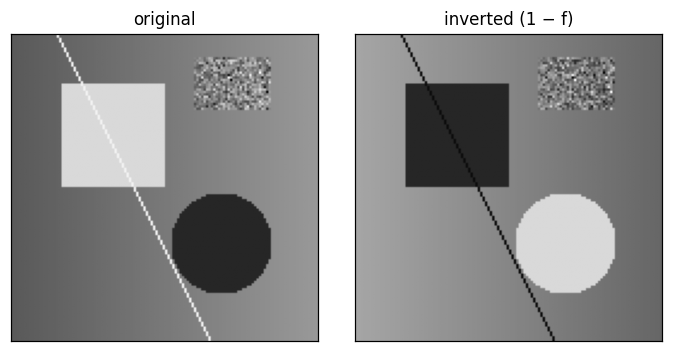

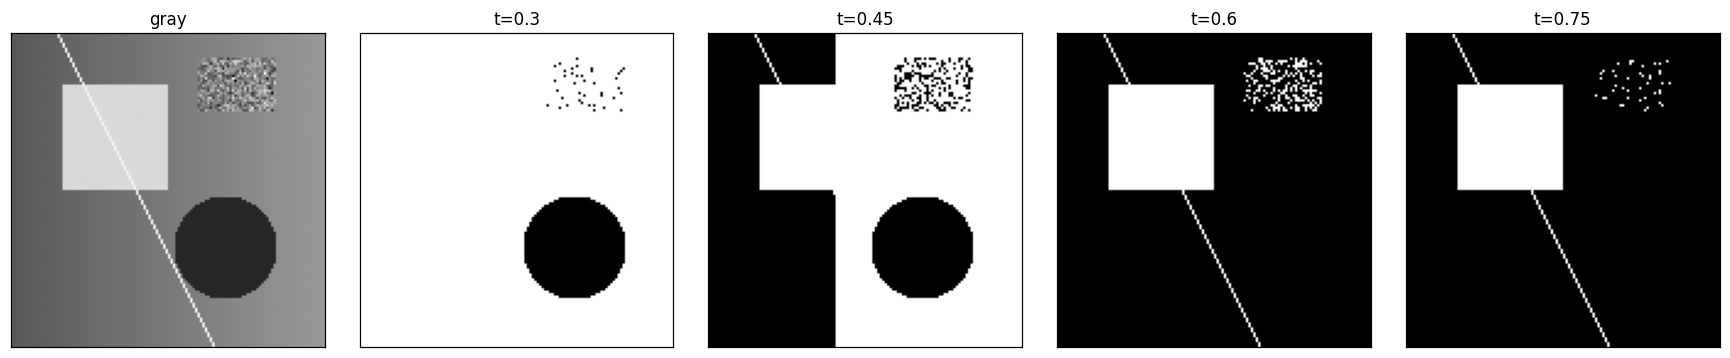

Otsu picked t = 0.647
max change on re-equalization: 0.0803


In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. tersleme g = 1 - f eğrisidir (aşağı doğru bir köşegen)
show_row([img, 1 - img], ["orijinal", "terslenmiş (1 − f)"])
plt.show()

# 2. eşik taraması
ts = [0.3, 0.45, 0.6, 0.75]
show_row([img] + [(img > t).astype(float) for t in ts],
         ["gri"] + [f"t={t}" for t in ts])
plt.show()
print("Otsu'nun seçtiği t =", round(otsu_threshold(img), 3))

# 3. yeniden eşitleme çok az değiştirir: eşitlenmiş bir görüntünün CDF'si zaten ~doğrusaldır
eq1 = equalize(low); eq2 = equalize(eq1)
print("yeniden eşitlemedeki maks değişim:", round(np.max(np.abs(eq2 - eq1)), 4))

## Recap & what's next

Point operations remap each pixel through a curve; the histogram summarizes the intensity
distribution; Otsu picks thresholds automatically; equalization uses the CDF to maximize contrast.
All of this is per-pixel — no neighbor ever consulted.

**Next — `03_convolution_from_scratch.ipynb`:** we finally let pixels talk to their neighbors.
**Convolution** — sliding a small kernel over the image — is the operation that defines linear
filtering and, ultimately, convolutional networks.

---
*Computer Vision · Week 1 · Lecture 2*